# Proposal Visualizations 2 & 3

This notebook builds the two visualizations our proposal commits to that are **not**
already produced in `analysis.ipynb`:

| # | Visualization | What it answers |
|---|---------------|-----------------|
| **2** | **SPLOM** — 3 socioeconomic predictors x 3 utilization measures, colored by Census region, with a trend line per panel | RQ2: direction, strength, and linearity of each socioeconomic <-> utilization relationship, plus regional clustering |
| **3** | **Residual map** (diverging choropleth of actual - predicted) **+ ranked residual bar chart** | RQ4: which counties/regions have utilization that is unexpectedly high or low given local socioeconomics |

### How to use this notebook
These cells are **drop-ins for `analysis.ipynb`**. They reuse objects that notebook
already creates, so run them *after* those cells:

- From the data load: `analysis_df`, `utilization_cols`, `socioeconomic_cols`
- From the modeling cell: `best_tree_by_target`, `holdout_predictions`, `test_idx`

If you run this as a standalone notebook, first execute `analysis.ipynb` up through the
modeling and residual cells **in the same kernel** so those variables exist in memory.

**Dependencies** (already in `requirements.txt`): `plotly`, `seaborn`, `matplotlib`,
`pandas`, `numpy`.

## 0. Imports

We use **seaborn/matplotlib** for the SPLOM (a static small-multiple grid reads more
cleanly for six variables) and **plotly** for the residual map and bar chart (interactive,
and consistent with the choropleths already in `analysis.ipynb`).

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 'talk' context = larger fonts suitable for a report/presentation
sns.set_theme(style="whitegrid", context="talk")

In [5]:
# Load the merged dataset directly so this notebook stands alone
analysis_df = pd.read_csv(
    "data/processed/medicare_acs_analysis.csv",
    dtype={"fips": str}          # keep leading zeros on FIPS
)
analysis_df = analysis_df.dropna().copy()   # matches analysis.ipynb's cleaning

# Recreate the column groups the cells below expect
utilization_cols = ["inpatient_stays_per_1000",
                    "outpatient_visits_per_1000",
                    "er_visits_per_1000"]
socioeconomic_cols = ["median_household_income",
                      "poverty_rate",
                      "bachelors_or_higher_pct"]

print(f"Loaded {len(analysis_df):,} counties")

Loaded 3,129 counties


## 1. Shared helper - map each county to its Census region

The SPLOM colors points by **Census region** (Northeast / Midwest / South / West) so we
can see whether relationships cluster geographically *before* modeling.

The county FIPS code is 5 digits where the **first 2 digits are the state FIPS code**.
We map each state FIPS to its Census region using the official Census Bureau regional
definitions, then attach a `census_region` column to `analysis_df`.

> This modifies `analysis_df` in place by adding two columns (`state_fips`,
> `census_region`). It is safe to re-run.

In [6]:
# Official U.S. Census Bureau region assignments, keyed by 2-digit state FIPS code
CENSUS_REGION_BY_STATE_FIPS = {
    # Northeast
    "09": "Northeast", "23": "Northeast", "25": "Northeast", "33": "Northeast",
    "34": "Northeast", "36": "Northeast", "42": "Northeast", "44": "Northeast",
    "50": "Northeast",
    # Midwest
    "17": "Midwest", "18": "Midwest", "19": "Midwest", "20": "Midwest", "26": "Midwest",
    "27": "Midwest", "29": "Midwest", "31": "Midwest", "38": "Midwest", "39": "Midwest",
    "46": "Midwest", "55": "Midwest",
    # South
    "01": "South", "05": "South", "10": "South", "11": "South", "12": "South", "13": "South",
    "21": "South", "22": "South", "24": "South", "28": "South", "37": "South", "40": "South",
    "45": "South", "47": "South", "48": "South", "51": "South", "54": "South",
    # West
    "02": "West", "04": "West", "06": "West", "08": "West", "15": "West", "16": "West",
    "30": "West", "32": "West", "35": "West", "41": "West", "49": "West", "53": "West",
    "56": "West",
}

# zfill(5) guards against FIPS codes that lost a leading zero; first 2 chars = state
analysis_df["state_fips"] = analysis_df["fips"].str.zfill(5).str[:2]
analysis_df["census_region"] = analysis_df["state_fips"].map(CENSUS_REGION_BY_STATE_FIPS)

# sanity check: counties per region (NaN = territories / unmapped)
analysis_df["census_region"].value_counts(dropna=False)

census_region
South        1418
Midwest      1055
West          447
Northeast     209
Name: count, dtype: int64

## 2. Visualization 2 - Scatterplot Matrix (SPLOM)

A SPLOM shows every pairwise relationship among our six variables at once:

- **Lower triangle:** scatter of each variable pair, points colored by Census region
- **Diagonal:** the distribution (histogram) of each variable
- **Upper triangle:** a fitted linear trend line with the **Pearson r** in the panel title

This gives a compact, at-a-glance view of the direction, strength, and linearity of each
bivariate relationship, and lets us spot regional clustering before we model anything.

### 2a. Choose the variables and friendly labels

`splom_vars` is the 3 socioeconomic predictors followed by the 3 utilization measures.
`pretty` maps the long column names to short labels so the axis text stays readable in a
6x6 grid.

In [7]:
# 3 ACS predictors + 3 CMS utilization measures = 6 variables -> 6x6 grid
splom_vars = socioeconomic_cols + utilization_cols

# short, human-readable labels for the axes
pretty = {
    "median_household_income": "Median HH income",
    "poverty_rate": "Poverty rate",
    "bachelors_or_higher_pct": "Bachelor's+ %",
    "inpatient_stays_per_1000": "Inpatient/1k",
    "outpatient_visits_per_1000": "Outpatient/1k",
    "er_visits_per_1000": "ED/1k",
}

# drop rows missing any plotted variable or the region (so coloring is clean)
splom_df = analysis_df.dropna(subset=splom_vars + ["census_region"]).copy()

# fixed region order so colors/legend are consistent every run
region_order = ["Northeast", "Midwest", "South", "West"]

print(f"{len(splom_df):,} counties plotted after dropping rows with missing values")

3,129 counties plotted after dropping rows with missing values


### 2b. Build the SPLOM

We use seaborn's `PairGrid` for full control over each triangle:

1. `PairGrid(...)` sets up the 6x6 grid, colored (`hue`) by region.
2. `map_lower(scatterplot)` fills the lower triangle with region-colored scatter points.
3. `map_diag(histplot)` puts a distribution on the diagonal.
4. The **loop** fills the upper triangle: for each pair above the diagonal we fit a
   simple line with `np.polyfit` and print the Pearson `r` as the panel title. (This is
   region-agnostic - one trend line over all counties - which is what we want for an
   overall association read.)
5. The last two loops replace the long column names with the `pretty` labels.

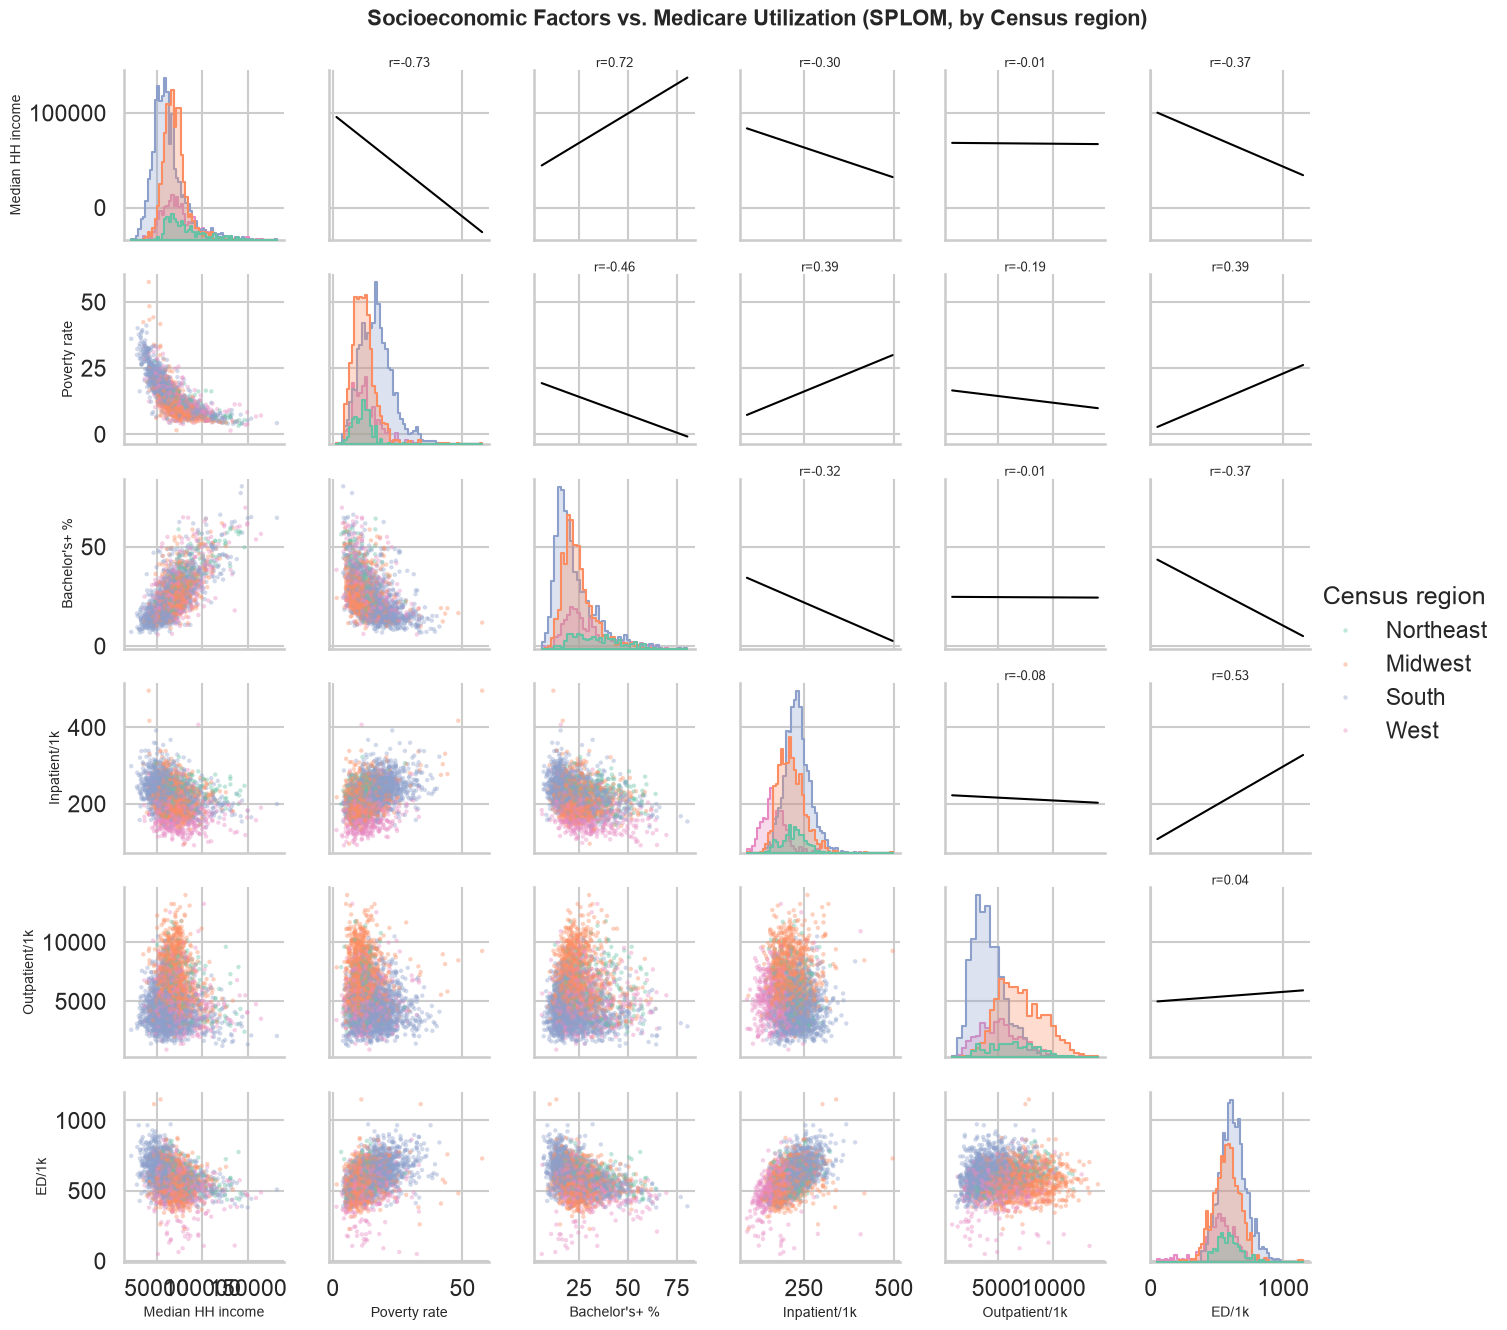

In [8]:
# 1) set up the grid, colored by Census region
g = sns.PairGrid(
    splom_df,
    vars=splom_vars,
    hue="census_region",
    hue_order=region_order,
    palette="Set2",
    diag_sharey=False,   # each diagonal histogram gets its own y-scale
    height=2.2,
    corner=False,        # we want the upper triangle too (for trend lines)
)

# 2) lower triangle: region-colored scatter
g.map_lower(sns.scatterplot, s=10, alpha=0.4, edgecolor="none")

# 3) diagonal: per-variable distribution
g.map_diag(sns.histplot, element="step", fill=True, alpha=0.3)

# 4) upper triangle: overall linear trend line + Pearson r in the title
for i, yv in enumerate(splom_vars):
    for j, xv in enumerate(splom_vars):
        if j <= i:
            continue  # only the strictly-upper triangle
        ax = g.axes[i, j]
        sub = splom_df[[xv, yv]].dropna()
        if len(sub) > 2:
            m, b = np.polyfit(sub[xv], sub[yv], 1)           # slope, intercept
            xs = np.linspace(sub[xv].min(), sub[xv].max(), 50)
            ax.plot(xs, m * xs + b, color="black", lw=1.5)   # trend line
            r = sub[xv].corr(sub[yv])                         # Pearson correlation
            ax.set_title(f"r={r:.2f}", fontsize=9, pad=2)

# 5) replace long column names with short labels on the outer axes
for ax, var in zip(g.axes[-1, :], splom_vars):   # bottom row -> x labels
    ax.set_xlabel(pretty[var], fontsize=10)
for ax, var in zip(g.axes[:, 0], splom_vars):    # left column -> y labels
    ax.set_ylabel(pretty[var], fontsize=10)

g.add_legend(title="Census region")
g.figure.suptitle(
    "Socioeconomic Factors vs. Medicare Utilization (SPLOM, by Census region)",
    y=1.02, fontsize=16, weight="bold",
)

# save a copy for the report, then show inline
g.figure.savefig("viz2_splom.png", dpi=120, bbox_inches="tight")
plt.show()

**How to read it:** In the upper triangle, the sign and size of `r` summarize each
relationship (e.g., poverty rate vs. ED visits is positive; education vs. ED visits is
negative). In the lower triangle, look for color separation - if one region's points sit
apart from the others, that relationship has a regional component worth noting in the
report.

## 3. Visualization 3 - Residual map + ranked residual bar chart

After modeling utilization from socioeconomic factors, the **residual** (actual -
predicted) tells us where reality departs from what the model expects:

- **Positive residual** -> the county uses *more* care than its socioeconomics predict
- **Negative residual** -> it uses *less*

Mapping residuals reveals regions where something **beyond** our socioeconomic features
(e.g., provider supply, hospital access, state policy) is likely driving utilization -
which directly addresses RQ4.

> **Important:** residuals are computed only on the **20% held-out test counties** from
> the `GroupShuffleSplit`, never on training data. That is correct practice - but it
> means the map is intentionally sparse (training-split states appear blank).

### 3a. Assemble the residual table from the fitted model

We pull the chosen model and its held-out predictions for one target (default:
emergency-department visits). Change `TARGET` to produce the inpatient or outpatient
versions. We then build a tidy table with actual, predicted, and residual per test county.

In [9]:
# pick which utilization outcome to inspect
TARGET = "er_visits_per_1000"  # or "inpatient_stays_per_1000" / "outpatient_visits_per_1000"

# look up the best model chosen for this target and its held-out predictions
best_info = best_tree_by_target[TARGET]
key = (TARGET, best_info["feature_set"], best_info["model_name"])
y_test, predictions = holdout_predictions[key]

# build the residual table for the held-out test counties
resid = analysis_df.iloc[test_idx][["fips", "county_name"]].copy()
resid["actual"] = y_test.to_numpy()
resid["predicted"] = predictions
resid["residual"] = resid["actual"] - resid["predicted"]
resid["fips"] = resid["fips"].str.zfill(5)   # keep FIPS as 5-digit strings for plotly

print(f"{len(resid):,} held-out counties with residuals for {TARGET}")
resid.head()

NameError: name 'best_tree_by_target' is not defined

### 3b. Diverging residual choropleth

A red-blue diverging scale centered at zero: **red = more** care than predicted, **blue =
less**. We clip the color range at the 98th percentile of |residual| so a few extreme
counties do not wash out the rest of the map.

In [ ]:
# symmetric color range, clipped at the 98th percentile so outliers don't dominate
rmax = resid["residual"].abs().quantile(0.98)

fig_map = px.choropleth(
    resid,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",                 # matches the 5-digit FIPS in the geojson
    color="residual",
    color_continuous_scale="RdBu_r",  # red = positive residual, blue = negative
    range_color=(-rmax, rmax),        # symmetric around 0
    scope="usa",
    hover_name="county_name",
    hover_data={"actual": ":.0f", "predicted": ":.0f", "residual": ":.0f", "fips": False},
    labels={"residual": "Actual - Predicted"},
    title=(f"Where ED Use Is Higher/Lower Than Socioeconomics Predict<br>"
           f"<sup>Model residuals on held-out counties - {TARGET.replace('_', ' ')}</sup>"),
)
fig_map.update_layout(margin=dict(l=0, r=0, t=70, b=0))

# save a static copy for the report (needs kaleido); comment out if kaleido not installed
fig_map.write_image("viz3a_residual_map.png", width=1200, height=700, scale=2)
fig_map.show()

### 3c. Ranked residual bar chart

The map shows *where*; this bar chart names *which* counties. We take the 20 largest
positive and 20 largest negative residuals, color them by direction, and order the bars
from most-negative to most-positive so the chart reads cleanly from bottom to top.

In [ ]:
# 20 biggest over-users and 20 biggest under-users
top_pos = resid.nlargest(20, "residual")
top_neg = resid.nsmallest(20, "residual")

ranked = pd.concat([top_neg, top_pos]).sort_values("residual")
ranked["direction"] = np.where(
    ranked["residual"] >= 0, "Higher than predicted", "Lower than predicted"
)

fig_bar = px.bar(
    ranked,
    x="residual",
    y="county_name",
    color="direction",
    orientation="h",
    color_discrete_map={
        "Higher than predicted": "#B2182B",  # red
        "Lower than predicted": "#2166AC",   # blue
    },
    labels={"residual": "Residual (actual - predicted)", "county_name": ""},
    title=f"Counties With the Largest Residuals - {TARGET.replace('_', ' ')}",
)
# force the y-axis to follow our sorted order (most negative at bottom)
fig_bar.update_layout(
    height=900, margin=dict(l=0, r=0, t=60, b=0),
    yaxis={"categoryorder": "array", "categoryarray": ranked["county_name"].tolist()},
)

fig_bar.write_image("viz3b_residual_bar.png", width=1100, height=900, scale=2)
fig_bar.show()

### Notes for the write-up

- To produce the **inpatient** and **outpatient** versions, change `TARGET` in 3a and
  re-run 3a-3c.
- `write_image(...)` requires `kaleido` (`pip install kaleido` + `plotly_get_chrome`).
  If you only need the figures displayed in the notebook, delete those two lines.
- Because residuals are from held-out counties only, describe the map as a *sample* of
  counties, and tie clustered residuals back to the **omitted-variable** point in the
  ethics section (provider supply, hospital access, Medicare Advantage penetration, etc.).